
# Comparação de Modelos: NLL, Acurácia e RMSE - Retweet (Dados Originais)

Neste notebook, compararemos **NHP, AttNHP, THP, RoTHP e RoTHP Híbrido** no dataset **Retweet** utilizando os **dados originais** (sem Time Shift artificial).

**Modelos:**
- **NHP** (Neural Hawkes Process): RNN com LSTM de tempo contínuo + decay exponencial
- **THP** (Transformer Hawkes Process): Transformer com decay linear entre eventos
- **RoTHP**: THP com Rotary Position Embeddings (RoPE)
- **RoTHP Híbrido**: THP com RoPE + Positional Encoding absoluto

**Configurações:**
- Dataset: `easytpp/retweet` (20k seqs treino, avg ~109 eventos/seq)
- Shift: 0.0 (Dados Originais)
- Model Capacity: Hidden Size 64, 2 Layers, 2 Heads (Alinhado com configs oficiais EasyTPP)

**CORREÇÃO IMPORTANTE (Attention Mask):**
A convenção do EasyTPP é `mask > 0 = BLOQUEAR` (usando `triu`). Versões anteriores deste notebook usavam `tril` (convenção invertida), o que fazia os Transformers atenderem ao futuro em vez do passado. Esta versão está corrigida.


In [1]:

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import DataLoader

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import Models
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_rothp_hybrid import RoTHPHybrid
from easy_tpp.model.torch_model.torch_thp import THP
from easy_tpp.model.torch_model.torch_nhp import NHP
from easy_tpp.model.torch_model.torch_thp_expdecay import THPExpDecay
from easy_tpp.model.torch_model.torch_attnhp import AttNHP

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


In [2]:

# =============================================================================
# CARREGAR DATASET
# =============================================================================
dataset_name = "easytpp/retweet" 
print(f"Carregando dataset '{dataset_name}'...")
dataset = load_dataset(dataset_name)

train_data = dataset['train']
test_data = dataset['test']

print(f"\nDataset carregado!")
print(f"Treino: {len(train_data)} sequências")
print(f"Teste:  {len(test_data)} sequências")

# =============================================================================
# EXTRAÇÃO AUTOMÁTICA DE METADADOS
# =============================================================================
def get_dataset_specs(data):
    max_type = 0
    for item in data:
        types = item['type_event']
        if len(types) > 0:
            current_max = max(types)
            if current_max > max_type:
                max_type = current_max
    
    # Assumindo IDs sequenciais 0, 1, ..., max_type
    num_types = max_type + 1
    return num_types

# Calcular specs baseados no treino
NUM_EVENT_TYPES = get_dataset_specs(train_data)
PAD_TOKEN_ID = NUM_EVENT_TYPES
NUM_EVENT_TYPES_PAD = NUM_EVENT_TYPES + 1

print(f"\nMetadados detectados automaticamente:")
print(f"Num Event Types: {NUM_EVENT_TYPES}")
print(f"Pad Token ID:    {PAD_TOKEN_ID}")
print(f"Total Vocab:     {NUM_EVENT_TYPES_PAD}")

# Estatísticas de comprimento de sequência
seq_lengths = [len(item['time_since_start']) for item in train_data]
print(f"\nEstatísticas de Comprimento de Sequência (Treino):")
print(f"  Média:   {np.mean(seq_lengths):.1f}")
print(f"  Mediana: {np.median(seq_lengths):.1f}")
print(f"  Min:     {np.min(seq_lengths)}")
print(f"  Max:     {np.max(seq_lengths)}")
print(f"  Std:     {np.std(seq_lengths):.1f}")

# Calcular escala temporal para normalização
all_deltas = []
for item in train_data:
    td = item['time_since_last_event']
    all_deltas.extend([d for d in td if d > 0])

TIME_SCALE = np.mean(all_deltas)
print(f"\nEscala Temporal (média dos deltas no treino):")
print(f"  Mean delta:   {TIME_SCALE:.4f}")
print(f"  Median delta: {np.median(all_deltas):.4f}")
print(f"  Max delta:    {np.max(all_deltas):.4f}")
print(f"  Min delta:    {np.min(all_deltas):.4f}")
print(f"  >> Todos os tempos serão divididos por {TIME_SCALE:.4f} para normalização")


Carregando dataset 'easytpp/retweet'...

Dataset carregado!
Treino: 20000 sequências
Teste:  2000 sequências

Metadados detectados automaticamente:
Num Event Types: 3
Pad Token ID:    3
Total Vocab:     4

Estatísticas de Comprimento de Sequência (Treino):
  Média:   108.8
  Mediana: 90.0
  Min:     50
  Max:     264
  Std:     54.5

Escala Temporal (média dos deltas no treino):
  Mean delta:   2704.2936
  Median delta: 40.0000
  Max delta:    582928.0000
  Min delta:    1.0000
  >> Todos os tempos serão divididos por 2704.2936 para normalização


In [3]:

# =============================================================================
# PREPARAÇÃO DE BATCH COM NORMALIZAÇÃO TEMPORAL
# =============================================================================

SHIFT_VAL = 0.0 

def collate_fn_shifted(batch_list):
    time_seqs = []
    time_delta_seqs = []
    type_seqs = []
    
    max_len = 0
    for item in batch_list:
        ts = item['time_since_start']
        td = item['time_since_last_event']
        ev = item['type_event']
        
        if len(ts) > max_len:
            max_len = len(ts)
            
        # NORMALIZAÇÃO TEMPORAL
        # 1. Subtrair t[0] para começar em 0
        ts_raw = torch.tensor(ts, dtype=torch.float64) + SHIFT_VAL
        ts_normalized = ts_raw - ts_raw[0]
        
        # 2. Dividir pela escala temporal (mean delta) para trazer valores para ~O(1)
        #    Isso é CRUCIAL para o THP, que usa decay LINEAR: factor * delta_t
        #    Sem normalização, delta_t pode ser ~1000+, explodindo a intensidade
        ts_final = (ts_normalized / TIME_SCALE).to(torch.float32)
        td_final = (torch.tensor(td, dtype=torch.float64) / TIME_SCALE).to(torch.float32)
        
        time_seqs.append(ts_final)
        time_delta_seqs.append(td_final) 
        type_seqs.append(torch.tensor(ev, dtype=torch.long))

    batch_size = len(batch_list)
    
    pad_time = torch.zeros(batch_size, max_len)
    pad_delta = torch.zeros(batch_size, max_len)
    pad_type = torch.zeros(batch_size, max_len, dtype=torch.long)
    attention_mask = torch.zeros(batch_size, max_len, max_len)
    batch_non_pad_mask = torch.zeros(batch_size, max_len)
    
    for i in range(batch_size):
        l = len(time_seqs[i])
        pad_time[i, :l] = time_seqs[i]
        pad_delta[i, :l] = time_delta_seqs[i]
        pad_type[i, :l] = type_seqs[i]
        batch_non_pad_mask[i, :l] = 1
        
        # MÁSCARA DE ATENÇÃO: Combina causal + padding (convenção EasyTPP: 1 = BLOQUEAR)
        # 1. Causal: triu(k=1) bloqueia posições futuras
        causal_mask = torch.triu(torch.ones(max_len, max_len), diagonal=1)
        # 2. Padding: bloqueia COLUNAS de padding (key positions que são padding)
        causal_mask[:, l:] = 1
        # 3. Padding rows: queries de padding bloqueiam tudo
        causal_mask[l:, :] = 1
        attention_mask[i] = causal_mask

    return (pad_time, pad_delta, pad_type, batch_non_pad_mask, attention_mask)

print(f"Collate function configurada com SHIFT = {SHIFT_VAL}")


Collate function configurada com SHIFT = 0.0


In [4]:

class ThinningConfig:
    def __init__(self, dtime_max=5.0, num_sample=200, num_exp=500):
        self.num_sample = num_sample     # Amostras para calcular a integral/predição
        self.num_exp = num_exp           # Amostras para o algoritmo de thinning
        self.over_sample_rate = 10.0
        self.patience_counter = 5
        self.num_samples_boundary = 20
        self.dtime_max = dtime_max       # Horizonte máximo de tempo para predição (em unidades normalizadas)

class ModelConfig:
    def __init__(self, num_types, pad_id, num_types_pad, hidden_size=64, num_heads=4, num_layers=2):
        self.hidden_size = hidden_size
        self.time_emb_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = 0.1
        self.use_ln = True
        
        # Specs Automáticos
        self.num_event_types = num_types
        self.num_event_types_pad = num_types_pad
        self.pad_token_id = pad_id
        
        self.loss_integral_num_sample_per_step = 20
        self.use_mc_samples = False
        self.gpu = -1
        
        # IMPORTANTE: Configuração de Thinning para habilitar .predict()
        self.thinning = ThinningConfig()
        
        # NHP Specifics
        self.model_specs = {'beta': 1.0, 'bias': True}

    def __str__(self):
        return str(self.__dict__)

print("Configuração definida com Thinning ativado.")


Configuração definida com Thinning ativado.


In [5]:

def compute_metrics(model, test_ds):
    model.eval()
    
    total_acc = 0
    total_rmse = 0
    total_events = 0
    
    # Avaliar em subset do teste para ser rápido (ex: 100 sequências)
    subset_size = min(100, len(test_ds))
    subset = [test_ds[i] for i in range(subset_size)]
    
    # Processar um por um ou em batches pequenos para evitar estourar memória na amostragem
    batch_size_eval = 10 
    
    with torch.no_grad():
        for i in range(0, subset_size, batch_size_eval):
            batch_list = subset[i:i+batch_size_eval]
            batch = collate_fn_shifted(batch_list)
            
            # Unpack batch para pegar targets
            # batch = (time_seqs, time_delta_seqs, type_seqs, batch_non_pad_mask, attention_mask)
            _, time_delta_target, type_target, mask_target, _ = batch
            
            # Predict
            # dtimes_pred: [B, L-1] (deltas previstos)
            # types_pred:  [B, L-1] (tipos previstos)
            dtimes_pred, types_pred = model.predict_one_step_at_every_event(batch)
            
            # Ajustar targets (removemos o primeiro evento pois não prevemos o passado, 
            # e o predict já remove o último evento da entrada para prever o próximo)
            # O output do predict alinha com o target do índice 1 ao fim.
            
            target_types = type_target[:, 1:]
            target_deltas = time_delta_target[:, 1:]
            target_mask = mask_target[:, 1:]
            
            # Calcular Acurácia (Type)
            correct = (types_pred == target_types) * target_mask
            total_acc += correct.sum().item()
            
            # Calcular RMSE (Time)
            se = ((dtimes_pred - target_deltas) ** 2) * target_mask
            total_rmse += se.sum().item()
            
            total_events += target_mask.sum().item()
            
    avg_acc = total_acc / (total_events + 1e-9)
    avg_rmse = np.sqrt(total_rmse / (total_events + 1e-9))
    
    return avg_acc, avg_rmse

def train_eval_loop(model_class, name, config, train_ds, test_ds, epochs=50, batch_size=64, lr=5e-4, patience=15):
    import time as time_module
    print(f"\n>>> Treinando: {name}")
    torch.manual_seed(42)
    model = model_class(config)
    
    # Contar parâmetros
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parâmetros treináveis: {num_params:,}")
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history_nll = []
    best_nll = float('inf')
    patience_counter = 0
    clip_val = 1.0 
    
    t_train_start = time_module.time()
    
    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        total_events = 0
        
        indices = np.random.permutation(len(train_ds))
        max_batches = 100
        
        for i in range(0, len(indices), batch_size):
            if i // batch_size > max_batches: break
            batch_idx = indices[i:i+batch_size]
            batch_list = [train_ds[int(k)] for k in batch_idx]
            
            try:
                batch_data = collate_fn_shifted(batch_list)
                optimizer.zero_grad()
                loss, num_events = model.loglike_loss(batch_data)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_val)
                optimizer.step()
                
                total_loss += loss.item()
                total_events += num_events
            except Exception as e:
                continue
            
        nll_train = total_loss / (total_events + 1e-9)
        
        # Validation NLL (batches menores para evitar padding excessivo)
        model.eval()
        val_loss_total = 0
        val_events_total = 0
        with torch.no_grad():
            test_subset = [test_ds[i] for i in range(min(200, len(test_ds)))]
            val_batch_size = 32
            for vi in range(0, len(test_subset), val_batch_size):
                val_batch = collate_fn_shifted(test_subset[vi:vi+val_batch_size])
                vl, vn = model.loglike_loss(val_batch)
                if not (torch.isnan(vl) or torch.isinf(vl)):
                    val_loss_total += vl.item()
                    val_events_total += vn
        nll_test = val_loss_total / (val_events_total + 1e-9)
        
        print(f"  Ep {epoch} | Train NLL: {nll_train:.4f} | Val NLL: {nll_test:.4f}")
        history_nll.append(nll_test)
        
        scheduler.step(nll_test)
        
        if nll_test < best_nll:
            best_nll = nll_test
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  >>> Early Stopping.")
                break
    
    t_train_end = time_module.time()
    train_time = t_train_end - t_train_start
    num_epochs_run = len(history_nll)
    
    # Final Metrics Calculation
    print(f"  Calculando métricas finais (Acc, RMSE)...")
    t_eval_start = time_module.time()
    final_acc, final_rmse = compute_metrics(model, test_ds)
    t_eval_end = time_module.time()
    eval_time = t_eval_end - t_eval_start
    
    total_time = train_time + eval_time
    print(f"  >>> Resultado Final {name}: Acc={final_acc:.4f}, RMSE={final_rmse:.4f}")
    print(f"  >>> Tempo: Treino={train_time:.1f}s ({num_epochs_run} épocas, {train_time/num_epochs_run:.1f}s/ep) | Eval={eval_time:.1f}s | Total={total_time:.1f}s")
    print(f"  >>> Parâmetros: {num_params:,}")
    
    return history_nll, final_acc, final_rmse, train_time, eval_time, num_params, model


In [6]:

config = ModelConfig(
    num_types=NUM_EVENT_TYPES,
    pad_id=PAD_TOKEN_ID,
    num_types_pad=NUM_EVENT_TYPES_PAD,
    hidden_size=64, 
    num_heads=2, 
    num_layers=2
)

results = {}

# Executar cada modelo individualmente (comente/descomente conforme necessário)

# --- NHP ---
hist, acc, rmse, t_train, t_eval, n_params, trained_model = train_eval_loop(NHP, "NHP (RNN)", config, train_data, test_data)
results["NHP (RNN)"] = {'hist': hist, 'acc': acc, 'rmse': rmse, 'train_time': t_train, 'eval_time': t_eval, 'total_time': t_train + t_eval, 'num_params': n_params, 'model': trained_model}

# --- THP ---
hist, acc, rmse, t_train, t_eval, n_params, trained_model = train_eval_loop(THP, "THP Tradicional", config, train_data, test_data)
results["THP Tradicional"] = {'hist': hist, 'acc': acc, 'rmse': rmse, 'train_time': t_train, 'eval_time': t_eval, 'total_time': t_train + t_eval, 'num_params': n_params, 'model': trained_model}

# --- THP-ExpDecay (PROPOSTO: Transformer + Exponential Decay) ---
hist, acc, rmse, t_train, t_eval, n_params, trained_model = train_eval_loop(THPExpDecay, "THP-ExpDecay (Proposto)", config, train_data, test_data)
results["THP-ExpDecay (Proposto)"] = {'hist': hist, 'acc': acc, 'rmse': rmse, 'train_time': t_train, 'eval_time': t_eval, 'total_time': t_train + t_eval, 'num_params': n_params, 'model': trained_model}

# --- RoTHP ---
hist, acc, rmse, t_train, t_eval, n_params, trained_model = train_eval_loop(RoTHP, "RoTHP (Transformer)", config, train_data, test_data)
results["RoTHP (Transformer)"] = {'hist': hist, 'acc': acc, 'rmse': rmse, 'train_time': t_train, 'eval_time': t_eval, 'total_time': t_train + t_eval, 'num_params': n_params, 'model': trained_model}

# --- RoTHP Híbrido ---
hist, acc, rmse, t_train, t_eval, n_params, trained_model = train_eval_loop(RoTHPHybrid, "RoTHP Híbrido", config, train_data, test_data)
results["RoTHP Híbrido"] = {'hist': hist, 'acc': acc, 'rmse': rmse, 'train_time': t_train, 'eval_time': t_eval, 'total_time': t_train + t_eval, 'num_params': n_params, 'model': trained_model}



>>> Treinando: NHP (RNN)
  Parâmetros treináveis: 58,246
  Ep 1 | Train NLL: -0.1831 | Val NLL: -0.9591
  Ep 2 | Train NLL: -1.2394 | Val NLL: -1.4444
  Ep 3 | Train NLL: -1.5828 | Val NLL: -1.6412
  Ep 4 | Train NLL: -1.6805 | Val NLL: -1.7253
  Ep 5 | Train NLL: -1.7676 | Val NLL: -1.7853
  Ep 6 | Train NLL: -1.8206 | Val NLL: -1.8368
  Ep 7 | Train NLL: -1.8653 | Val NLL: -1.8825
  Ep 8 | Train NLL: -1.9238 | Val NLL: -1.9280
  Ep 9 | Train NLL: -1.9548 | Val NLL: -1.9690
  Ep 10 | Train NLL: -1.9953 | Val NLL: -2.0107
  Ep 11 | Train NLL: -2.0312 | Val NLL: -2.0499
  Ep 12 | Train NLL: -2.0882 | Val NLL: -2.0886
  Ep 13 | Train NLL: -2.1193 | Val NLL: -2.1260
  Ep 14 | Train NLL: -2.1549 | Val NLL: -2.1624
  Ep 15 | Train NLL: -2.1841 | Val NLL: -2.1975
  Ep 16 | Train NLL: -2.2279 | Val NLL: -2.2322
  Ep 17 | Train NLL: -2.2707 | Val NLL: -2.2669
  Ep 18 | Train NLL: -2.2958 | Val NLL: -2.2998
  Ep 19 | Train NLL: -2.3291 | Val NLL: -2.3327
  Ep 20 | Train NLL: -2.3652 | Val NLL:

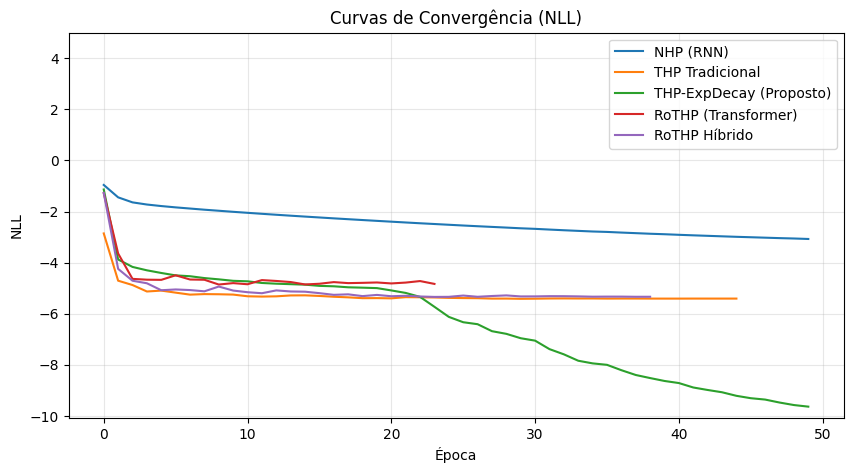

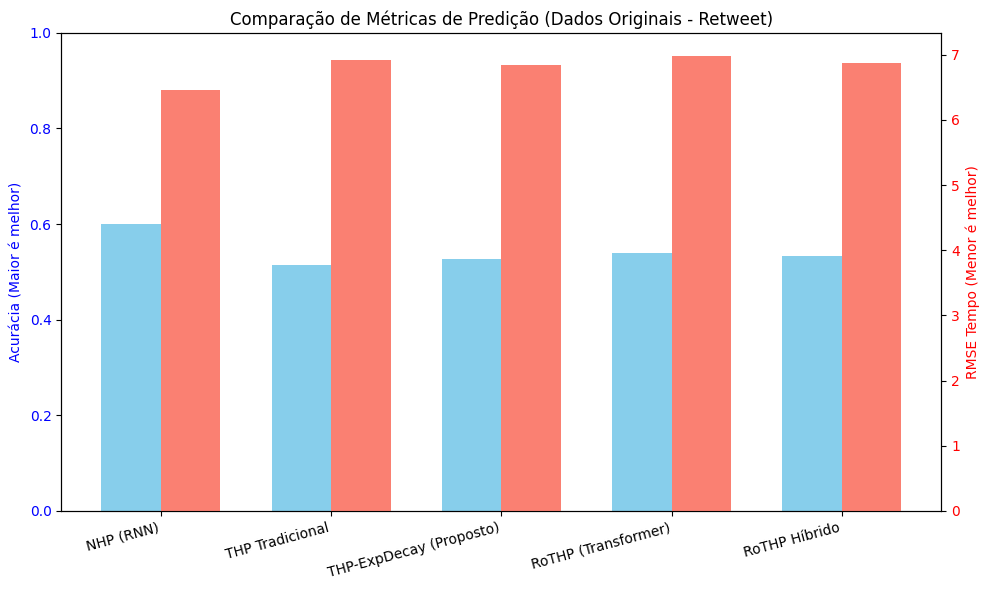

                 Modelo  Acurácia  RMSE Tempo  Final NLL  Treino (s)  Eval (s)   Total (s)  Parâmetros
              NHP (RNN)  0.599122    6.464277  -3.073913 4694.339498 45.707608 4740.047106       58246
        THP Tradicional  0.513861    6.914355  -5.407350 1930.392507 37.880630 1968.273137       41996
THP-ExpDecay (Proposto)  0.527523    6.851108  -9.637203 2162.220923 37.166240 2199.387163       41996
    RoTHP (Transformer)  0.538492    6.987800  -4.832985 1143.017351 36.838901 1179.856252       41996
          RoTHP Híbrido  0.532708    6.877413  -5.335836 1872.045911 37.674042 1909.719953       41996


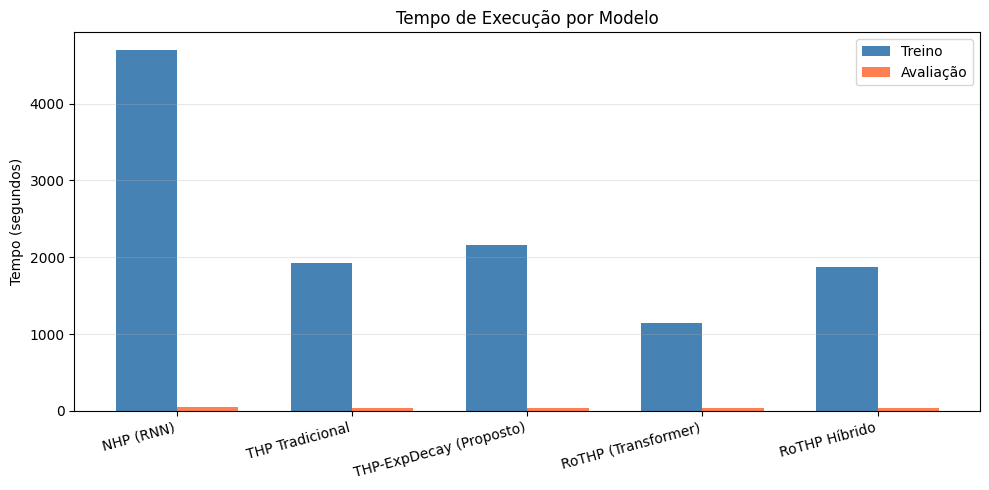

In [7]:

# Plot 1: NLL Curves
plt.figure(figsize=(10, 5))
for name, res in results.items():
    plt.plot(res['hist'], label=f"{name}")
plt.xlabel('Época')
plt.ylabel('NLL')
plt.title('Curvas de Convergência (NLL)')
plt.ylim(top=5) # Zoom
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Bar Chart Metrics
names = list(results.keys())
accs = [results[n]['acc'] for n in names]
rmses = [results[n]['rmse'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy bars (Axis 1)
rects1 = ax1.bar(x - width/2, accs, width, label='Acurácia', color='skyblue')
ax1.set_ylabel('Acurácia (Maior é melhor)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 1.0)

# RMSE bars (Axis 2)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, rmses, width, label='RMSE Time', color='salmon')
ax2.set_ylabel('RMSE Tempo (Menor é melhor)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15, ha='right')
ax1.set_title(f'Comparação de Métricas de Predição (Dados Originais - Retweet)')

fig.tight_layout()
plt.show()

# Tabela resumo
import pandas as pd
df_res = pd.DataFrame({
    'Modelo': names,
    'Acurácia': accs,
    'RMSE Tempo': rmses,
    'Final NLL': [results[n]['hist'][-1] for n in names],
    'Treino (s)': [results[n]['train_time'] for n in names],
    'Eval (s)': [results[n]['eval_time'] for n in names],
    'Total (s)': [results[n]['total_time'] for n in names],
    'Parâmetros': [results[n]['num_params'] for n in names],
})
print(df_res.to_string(index=False))

# Plot 3: Tempo de Execução
fig, ax = plt.subplots(figsize=(10, 5))
train_times = [results[n]['train_time'] for n in names]
eval_times = [results[n]['eval_time'] for n in names]
ax.bar(x - width/2, train_times, width, label='Treino', color='steelblue')
ax.bar(x + width/2, eval_times, width, label='Avaliação', color='coral')
ax.set_ylabel('Tempo (segundos)')
ax.set_title('Tempo de Execução por Modelo')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()


ANÁLISE DE SENSIBILIDADE: Thinning Config vs Métricas de Predição

--- Config: dmax=1.0 ---
  NHP (RNN)                 | Acc=0.5993 | RMSE=6.4593 | Time=42.2s
  THP Tradicional           | Acc=0.5128 | RMSE=6.9316 | Time=34.8s
  THP-ExpDecay (Proposto)   | Acc=0.5325 | RMSE=6.8577 | Time=33.1s
  RoTHP (Transformer)       | Acc=0.5366 | RMSE=6.9944 | Time=30.2s
  RoTHP Híbrido             | Acc=0.5325 | RMSE=6.9010 | Time=29.5s

--- Config: dmax=2.0 ---
  NHP (RNN)                 | Acc=0.5996 | RMSE=6.4779 | Time=37.0s
  THP Tradicional           | Acc=0.5128 | RMSE=6.9242 | Time=33.6s
  THP-ExpDecay (Proposto)   | Acc=0.5313 | RMSE=6.8464 | Time=31.4s
  RoTHP (Transformer)       | Acc=0.5353 | RMSE=6.9956 | Time=36.3s
  RoTHP Híbrido             | Acc=0.5311 | RMSE=6.8954 | Time=28.9s

--- Config: dmax=3.0 ---
  NHP (RNN)                 | Acc=0.5988 | RMSE=6.4734 | Time=36.2s
  THP Tradicional           | Acc=0.5132 | RMSE=6.9278 | Time=30.3s
  THP-ExpDecay (Proposto)   | Acc=0.5293

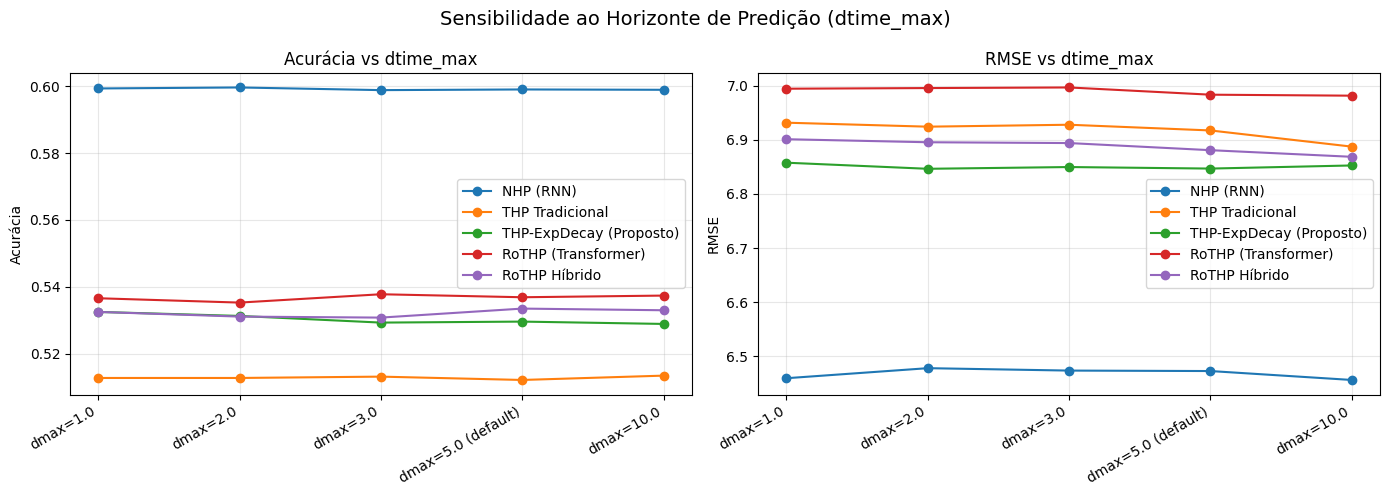

In [8]:

# =============================================================================
# ANÁLISE DE SENSIBILIDADE DO THINNING ALGORITHM
# =============================================================================
# Testa diferentes configs de thinning SEM retreinar os modelos.
# Isso mostra como os hiperparâmetros de predição afetam Acc/RMSE.

import time as time_module

thinning_configs = [
    {'dtime_max': 1.0,  'num_sample': 200, 'num_exp': 500, 'label': 'dmax=1.0'},
    {'dtime_max': 2.0,  'num_sample': 200, 'num_exp': 500, 'label': 'dmax=2.0'},
    {'dtime_max': 3.0,  'num_sample': 200, 'num_exp': 500, 'label': 'dmax=3.0'},
    {'dtime_max': 5.0,  'num_sample': 200, 'num_exp': 500, 'label': 'dmax=5.0 (default)'},
    {'dtime_max': 10.0, 'num_sample': 200, 'num_exp': 500, 'label': 'dmax=10.0'},
]

print("=" * 80)
print("ANÁLISE DE SENSIBILIDADE: Thinning Config vs Métricas de Predição")
print("=" * 80)

sensitivity_results = []

for tc in thinning_configs:
    print(f"\n--- Config: {tc['label']} ---")
    
    for name, res in results.items():
        model = res['model']
        
        # Recriar o EventSampler com novos parâmetros de thinning
        from easy_tpp.model.torch_model.torch_thinning import EventSampler
        model.event_sampler = EventSampler(
            num_sample=tc['num_sample'],
            num_exp=tc['num_exp'],
            over_sample_rate=10.0,
            num_samples_boundary=20,
            dtime_max=tc['dtime_max'],
            patience_counter=5,
            device=model.device
        )
        
        t0 = time_module.time()
        acc, rmse = compute_metrics(model, test_data)
        t1 = time_module.time()
        
        print(f"  {name:25s} | Acc={acc:.4f} | RMSE={rmse:.4f} | Time={t1-t0:.1f}s")
        sensitivity_results.append({
            'config': tc['label'],
            'model': name,
            'acc': acc,
            'rmse': rmse,
        })

# Tabela consolidada
df_sens = pd.DataFrame(sensitivity_results)
print("\n" + "=" * 80)
print("TABELA CONSOLIDADA")
print("=" * 80)
pivot_acc = df_sens.pivot(index='config', columns='model', values='acc')
pivot_rmse = df_sens.pivot(index='config', columns='model', values='rmse')
print("\nACURÁCIA:")
print(pivot_acc.to_string())
print("\nRMSE:")
print(pivot_rmse.to_string())

# Plot comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in results.keys():
    model_data = df_sens[df_sens['model'] == name]
    axes[0].plot(range(len(model_data)), model_data['acc'].values, 'o-', label=name)
    axes[1].plot(range(len(model_data)), model_data['rmse'].values, 'o-', label=name)

tick_labels = [tc['label'] for tc in thinning_configs]
axes[0].set_xticks(range(len(thinning_configs)))
axes[0].set_xticklabels(tick_labels, rotation=30, ha='right')
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia vs dtime_max')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xticks(range(len(thinning_configs)))
axes[1].set_xticklabels(tick_labels, rotation=30, ha='right')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE vs dtime_max')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Sensibilidade ao Horizonte de Predição (dtime_max)', fontsize=14)
fig.tight_layout()
plt.show()


Sequência 5: 114 eventos totais
Visualizando eventos 5 a 15
Tempos (normalizados): [0.07580538094043732, 0.1394079476594925, 0.17342790961265564, 0.3165336847305298, 0.32060128450393677]...
Tipos: [1, 1, 1, 1, 1]...

Computando intensidades e predições...
  NHP (RNN)...
  THP Tradicional...
  THP-ExpDecay (Proposto)...
  RoTHP (Transformer)...
  RoTHP Híbrido...


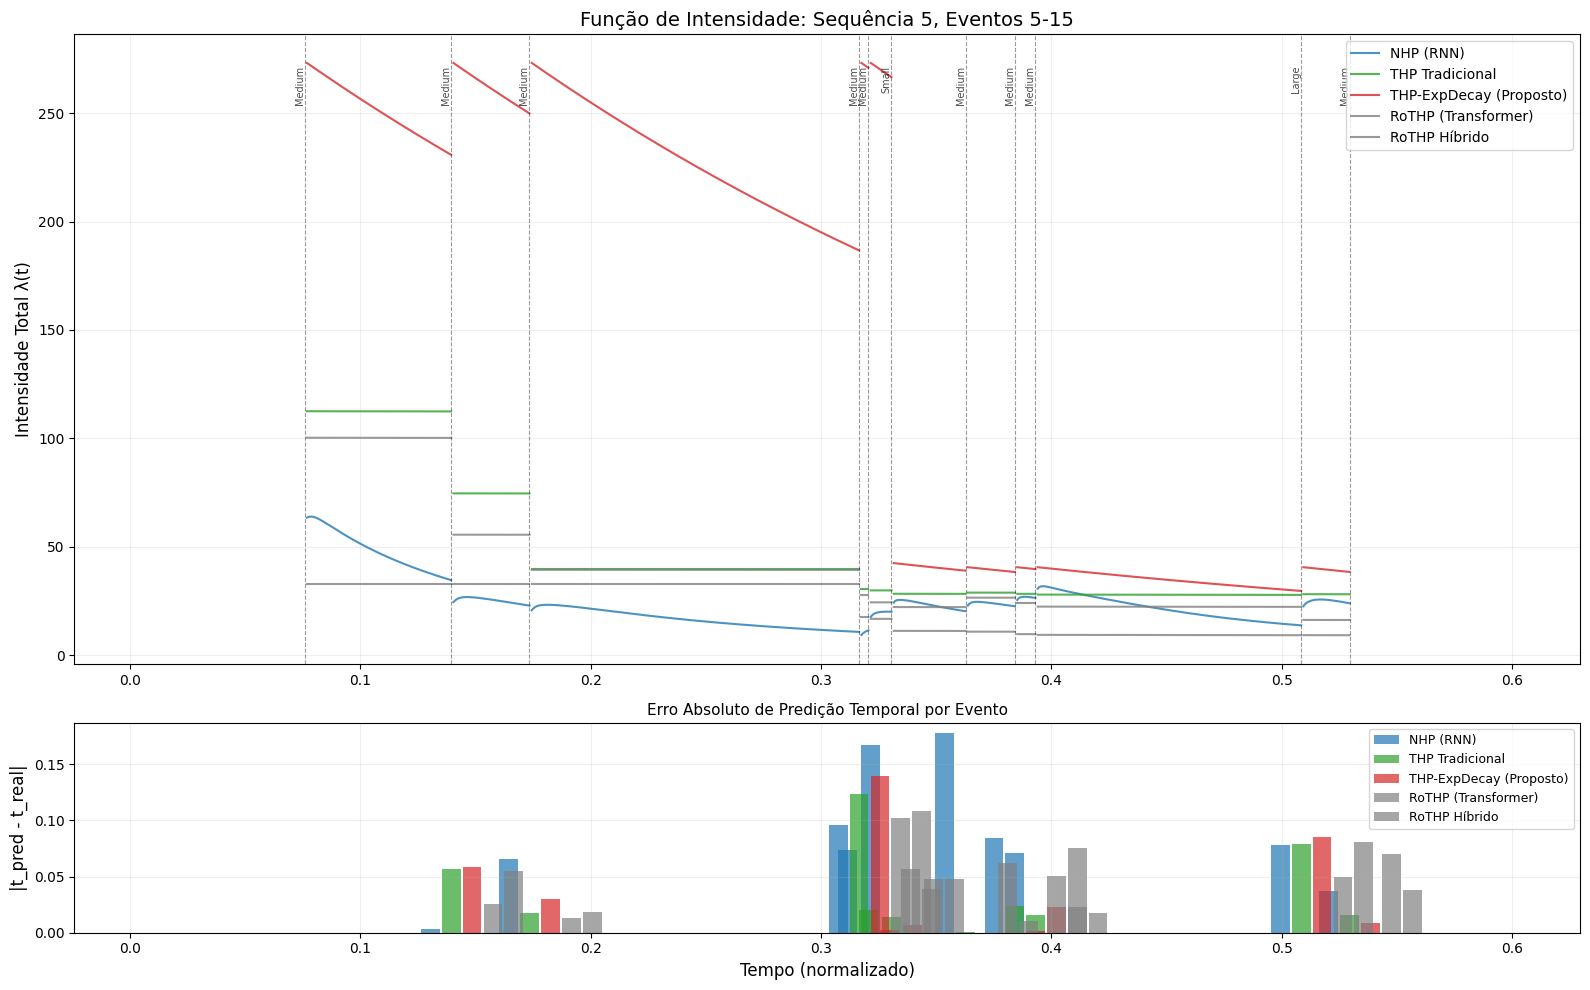

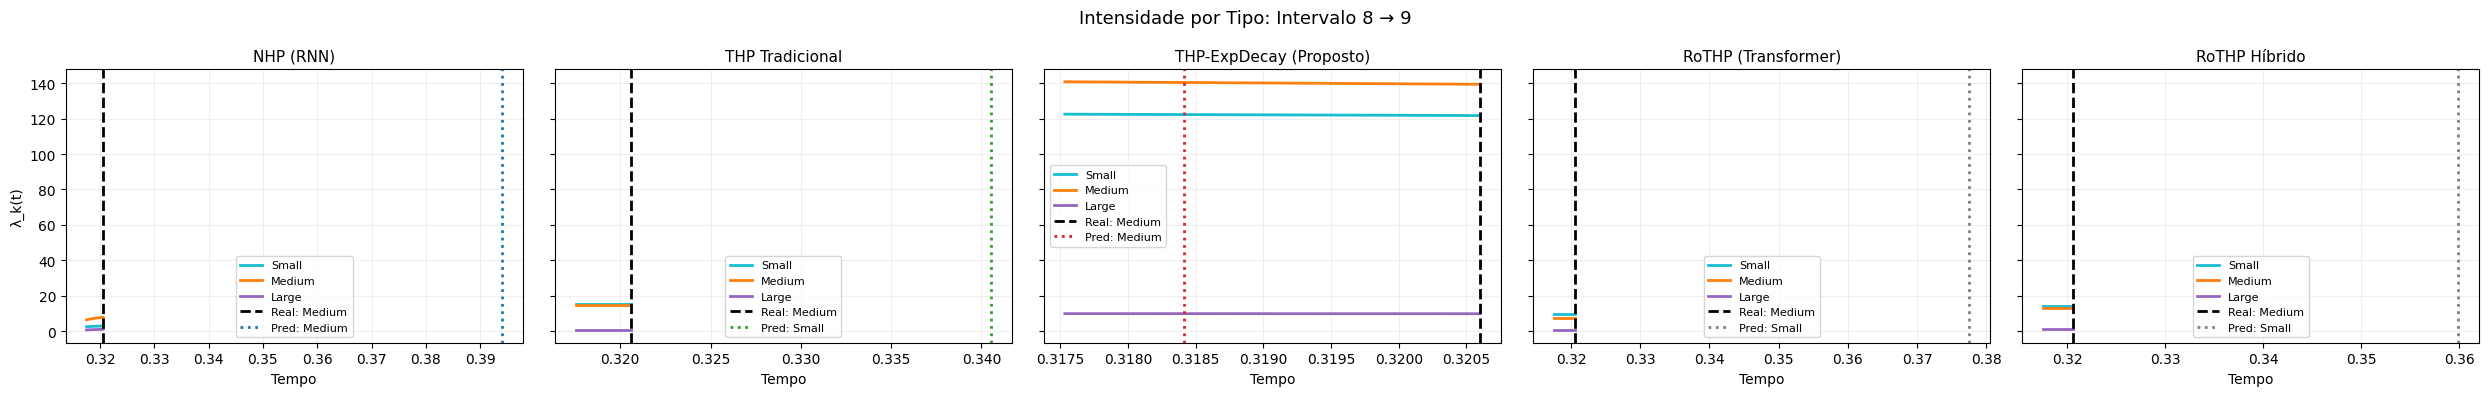


RESUMO: Predição por Evento
Ev    Real (tipo, t)         NHP (RNN)                 THP Tradicional           THP-ExpDecay (Prop        RoTHP (Transformer        RoTHP Híbrido            
--------------------------------------------------------------------------------
6     Medium, t=0.139        Medium OK dt=0.003     Small X  dt=0.056     Medium OK dt=0.059     Medium OK dt=0.025     Medium OK dt=0.055    
7     Medium, t=0.173        Medium OK dt=0.066     Small X  dt=0.017     Medium OK dt=0.030     Medium OK dt=0.013     Small X  dt=0.018    
8     Medium, t=0.317        Medium OK dt=0.096     Medium OK dt=0.123     Medium OK dt=0.140     Medium OK dt=0.102     Medium OK dt=0.109    
9     Medium, t=0.321        Medium OK dt=0.073     Small X  dt=0.020     Medium OK dt=0.002     Small X  dt=0.057     Small X  dt=0.039    
10    Small, t=0.331         Medium X  dt=0.168     Small OK dt=0.014     Medium X  dt=0.007     Small OK dt=0.048     Small OK dt=0.047    
11    Medium, t=0.36

In [9]:

# =============================================================================
# VISUALIZAÇÃO DA FUNÇÃO DE INTENSIDADE: NHP vs THP vs THP-ExpDecay
# =============================================================================
# Para uma sequência de teste, plotamos:
# 1. A função de intensidade λ(t) de cada modelo entre eventos consecutivos
# 2. Linhas verticais nos eventos reais
# 3. Predições de cada modelo

import matplotlib.patches as mpatches

# --- Configuração ---
SEQ_IDX = 5            # Qual sequência do teste usar
EVENT_RANGE = (5, 15)  # Faixa de eventos para visualizar
NUM_POINTS = 200       # Pontos para plotar a curva entre eventos

# Cores por modelo
model_colors = {
    'NHP (RNN)': 'tab:blue',
    'THP Tradicional': 'tab:green',
    'THP-ExpDecay (Proposto)': 'tab:red',
}
event_type_names = {0: 'Small', 1: 'Medium', 2: 'Large'}  # Retweet types

# --- Preparar a sequência ---
seq = test_data[SEQ_IDX]
ts_raw = torch.tensor(seq['time_since_start'], dtype=torch.float64)
ts_norm = ((ts_raw - ts_raw[0]) / TIME_SCALE).to(torch.float32)
td_raw = torch.tensor(seq['time_since_last_event'], dtype=torch.float64)
td_norm = (td_raw / TIME_SCALE).to(torch.float32)
types = torch.tensor(seq['type_event'], dtype=torch.long)

start_ev, end_ev = EVENT_RANGE
ts_slice = ts_norm[start_ev:end_ev+1]
types_slice = types[start_ev:end_ev+1]

print(f"Sequência {SEQ_IDX}: {len(ts_norm)} eventos totais")
print(f"Visualizando eventos {start_ev} a {end_ev}")
print(f"Tempos (normalizados): {ts_slice[:5].tolist()}...")
print(f"Tipos: {types_slice[:5].tolist()}...")

# --- Computar intensidade para cada modelo ---
def compute_intensity_curve(model, ts_full, td_full, types_full, start_ev, end_ev, num_points=200):
    model.eval()
    intervals = []
    
    with torch.no_grad():
        for i in range(start_ev, end_ev):
            t_start = ts_full[i].item()
            t_end = ts_full[i+1].item()
            type_next = types_full[i+1].item()
            
            if t_end <= t_start:
                continue
            
            # Grade de tempos entre t_i e t_{i+1}
            dt_grid = torch.linspace(0.001, t_end - t_start, num_points)
            
            # Preparar batch: sequência até o evento i (inclusive)
            seq_len = i + 1
            time_seq = ts_full[:seq_len].unsqueeze(0)
            td_seq = td_full[:seq_len].unsqueeze(0)
            type_seq = types_full[:seq_len].unsqueeze(0)
            sample_dtimes = dt_grid.unsqueeze(0).unsqueeze(0)
            
            try:
                intensities = model.compute_intensities_at_sample_times(
                    time_seq, td_seq, type_seq, 
                    sample_dtimes.expand(1, seq_len, num_points),
                    compute_last_step_only=True
                )
                
                # [num_points, num_types]
                intensity_values = intensities[0, 0, :, :].cpu().numpy()
                
                intervals.append({
                    't_grid': (dt_grid + t_start).numpy(),
                    'intensities': intensity_values,
                    't_start': t_start,
                    't_end': t_end,
                    'type_next': type_next,
                })
            except Exception as e:
                print(f"  Erro no intervalo {i}->{i+1}: {e}")
                continue
    
    return intervals

# --- Computar predições de cada modelo ---
def get_predictions_for_seq(model, ts_full, td_full, types_full, start_ev, end_ev):
    model.eval()
    
    seq_len = end_ev + 1
    batch = (
        ts_full[:seq_len].unsqueeze(0),
        td_full[:seq_len].unsqueeze(0),
        types_full[:seq_len].unsqueeze(0),
        torch.ones(1, seq_len),
        torch.triu(torch.ones(seq_len, seq_len), diagonal=1).unsqueeze(0)
    )
    
    with torch.no_grad():
        dtimes_pred, types_pred = model.predict_one_step_at_every_event(batch)
    
    preds = []
    for i in range(start_ev, end_ev):
        t_pred = ts_full[i].item() + dtimes_pred[0, i].item()
        type_pred = types_pred[0, i].item()
        preds.append({'t_pred': t_pred, 'type_pred': type_pred})
    
    return preds

# --- Computar tudo ---
print("\nComputando intensidades e predições...")
model_data = {}
for name, res in results.items():
    model = res['model']
    color = model_colors.get(name, 'gray')
    
    print(f"  {name}...")
    intervals = compute_intensity_curve(model, ts_norm, td_norm, types, start_ev, end_ev, NUM_POINTS)
    preds = get_predictions_for_seq(model, ts_norm, td_norm, types, start_ev, end_ev)
    model_data[name] = {'intervals': intervals, 'preds': preds, 'color': color}

# =============================================================================
# PLOT 1: Intensidade Total λ(t) + Erro de Predição
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})
ax_main = axes[0]
ax_err = axes[1]

# Curvas de intensidade
for name, md in model_data.items():
    color = md['color']
    for j, interval in enumerate(md['intervals']):
        total_intensity = interval['intensities'].sum(axis=1)
        label = name if j == 0 else None
        ax_main.plot(interval['t_grid'], total_intensity, color=color, alpha=0.8, linewidth=1.5, label=label)

# Eventos reais (linhas verticais)
for i in range(start_ev, end_ev + 1):
    t = ts_norm[i].item()
    etype = types[i].item()
    ax_main.axvline(x=t, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
    ylim = ax_main.get_ylim()
    ypos = ylim[1] * 0.95 if ylim[1] > 0 else 1.0
    ax_main.text(t, ypos, f'{event_type_names.get(etype, str(etype))}', 
                 rotation=90, va='top', ha='right', fontsize=7, color='black', alpha=0.7)

ax_main.set_ylabel('Intensidade Total λ(t)', fontsize=12)
ax_main.set_title(f'Função de Intensidade: Sequência {SEQ_IDX}, Eventos {start_ev}-{end_ev}', fontsize=14)
ax_main.legend(loc='upper right', fontsize=10)
ax_main.grid(True, alpha=0.2)
ax_main.set_xlim(ts_norm[start_ev].item() - 0.1, ts_norm[end_ev].item() + 0.1)

# Erro de predição temporal
bar_width = (ts_norm[end_ev].item() - ts_norm[start_ev].item()) / (end_ev - start_ev) * 0.2
for mi, (name, md) in enumerate(model_data.items()):
    errors = []
    positions = []
    for j, pred in enumerate(md['preds']):
        t_real = ts_norm[start_ev + j + 1].item()
        errors.append(abs(pred['t_pred'] - t_real))
        positions.append(t_real + (mi - 1) * bar_width)
    ax_err.bar(positions, errors, width=bar_width * 0.9, color=md['color'], alpha=0.7, label=name)

ax_err.set_xlabel('Tempo (normalizado)', fontsize=12)
ax_err.set_ylabel('|t_pred - t_real|', fontsize=12)
ax_err.set_title('Erro Absoluto de Predição Temporal por Evento', fontsize=11)
ax_err.legend(fontsize=9)
ax_err.grid(True, alpha=0.2)
ax_err.set_xlim(ts_norm[start_ev].item() - 0.1, ts_norm[end_ev].item() + 0.1)

fig.tight_layout()
plt.show()

# =============================================================================
# PLOT 2: Intensidade por Tipo (detalhe de 1 intervalo)
# =============================================================================
DETAIL_INTERVAL = 3

fig, axes = plt.subplots(1, len(model_data), figsize=(5 * len(model_data), 4), sharey=True)
if len(model_data) == 1:
    axes = [axes]

for idx, (name, md) in enumerate(model_data.items()):
    ax = axes[idx]
    
    if DETAIL_INTERVAL < len(md['intervals']):
        interval = md['intervals'][DETAIL_INTERVAL]
        type_colors = ['tab:cyan', 'tab:orange', 'tab:purple']
        
        for k in range(interval['intensities'].shape[1]):
            type_label = event_type_names.get(k, f'Type {k}')
            ax.plot(interval['t_grid'], interval['intensities'][:, k], 
                    color=type_colors[k % len(type_colors)], linewidth=2, label=type_label)
        
        ax.axvline(x=interval['t_end'], color='black', linestyle='--', linewidth=2, 
                   label=f'Real: {event_type_names.get(interval["type_next"], "?")}')
        
        pred = md['preds'][DETAIL_INTERVAL]
        ax.axvline(x=pred['t_pred'], color=md['color'], linestyle=':', linewidth=2,
                   label=f'Pred: {event_type_names.get(pred["type_pred"], "?")}')
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Tempo')
    if idx == 0:
        ax.set_ylabel('λ_k(t)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle(f'Intensidade por Tipo: Intervalo {start_ev+DETAIL_INTERVAL} → {start_ev+DETAIL_INTERVAL+1}', fontsize=13)
fig.tight_layout()
plt.show()

# =============================================================================
# Tabela resumo de predições por evento
# =============================================================================
print("\n" + "=" * 80)
print("RESUMO: Predição por Evento")
print("=" * 80)
print(f"{'Ev':<5} {'Real (tipo, t)':<22}", end='')
for name in model_data.keys():
    short = name[:18]
    print(f" {short:<25}", end='')
print()
print("-" * 80)

for j in range(min(end_ev - start_ev, 10)):
    real_t = ts_norm[start_ev + j + 1].item()
    real_type = types[start_ev + j + 1].item()
    real_label = event_type_names.get(real_type, str(real_type))
    
    print(f"{start_ev+j+1:<5} {real_label+', t='+f'{real_t:.3f}':<22}", end='')
    
    for name, md in model_data.items():
        pred = md['preds'][j]
        pred_label = event_type_names.get(pred['type_pred'], str(pred['type_pred']))
        t_err = abs(pred['t_pred'] - real_t)
        type_ok = 'OK' if pred['type_pred'] == real_type else 'X '
        print(f" {pred_label} {type_ok} dt={t_err:.3f}", end='    ')
    print()
